## STAT


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from src.transcripts import (
    load_all_transcripts,
    filter_only_participants,
    concat_text_per_participant,
)
from src.features import simple_features

In [2]:
df = load_all_transcripts()
print("Wszystkich wierszy (wypowiedzi):", len(df))
print("Uczestników:", df["participant_id"].nunique())
df.head()

Wszystkich wierszy (wypowiedzi): 14835
Uczestników: 38


,speaker_id,slide_id,question_id,problem_id,text,participant_id,group
0,DR,NaN,NaN,NaN,Transkrypcja została włączona i ona sobie tut...,DR_IT_05,IT
1,DR,NaN,NaN,NaN,Tak mamy.,DR_IT_05,IT
2,DR,NaN,NaN,NaN,"I zrobimy może w ten sposób, że ja panią zap...",DR_IT_05,IT
3,DR,NaN,NaN,NaN,Około pani.,DR_IT_05,IT
4,DR,NaN,NaN,NaN,Wszystko jest w porządku.,DR_IT_05,IT


In [3]:
df.drop_duplicates("participant_id")["group"].value_counts()

group
SSH    18
DE     12
IT      8
Name: count, dtype: int64

In [4]:
df[df["participant_id"] == "MW_SSH_05"].head(10)

,speaker_id,slide_id,question_id,problem_id,text,participant_id,group
7176,MW,NaN,NaN,NaN,"Będziemy pracować taką metodą, która nazywa si...",MW_SSH_05,SSH
7177,MW_SSH_05,NaN,NaN,NaN,"To będzie dość proste, bo już jestem (anonimiz...",MW_SSH_05,SSH
7178,MW,NaN,NaN,NaN,"Tak, doświadczony użytkownik badań, bardzo doc...",MW_SSH_05,SSH
7179,MW_SSH_05,NaN,NaN,NaN,Nieraz.,MW_SSH_05,SSH
7180,MW,NaN,NaN,NaN,"Nieraz, czyli rozumiem, że dodawanie, odejmowa...",MW_SSH_05,SSH
7181,MW_SSH_05,NaN,NaN,NaN,"Do komentarzy muszę się zastanowić, bo nie jes...",MW_SSH_05,SSH
7182,MW,NaN,NaN,NaN,"To możemy sobie wejść teraz do tego folderu, k...",MW_SSH_05,SSH
7183,MW_SSH_05,NaN,NaN,NaN,A (ns - 00:02:21).,MW_SSH_05,SSH
7184,MW,NaN,NaN,NaN,Będziemy wiedzieć. Czyli prezentację można sob...,MW_SSH_05,SSH
7185,MW_SSH_05,NaN,NaN,NaN,"Nigdy nie używałem komentarzy, nie próbowałem ...",MW_SSH_05,SSH


In [5]:
print("Przed filtracją:", len(df))
df_part = filter_only_participants(df)
print("Po filtracji (tylko uczestnicy):", len(df_part))

Przed filtracją: 14835
Po filtracji (tylko uczestnicy): 11434


In [6]:
text_df = concat_text_per_participant(df_part)
print("Ramka per uczestnik:", text_df.shape)
text_df.head()

Ramka per uczestnik: (38, 3)


,participant_id,group,text
0,DR_IT_05,IT,", czyli wzięły nam zostanie z niego. Że jest z..."
1,DR_SSH_01,SSH,"Tak, jestem gotowa Czyli odpowiedzieć mam na p..."
2,DR_SSH_02,SSH,W porządku zatem można tam póki co czytam pier...
3,DR_SSH_03,SSH,W takim razie czytam prezentację. Tam zapewn...
4,DR_SSH_04,SSH,"Czyli będę musiał wysyłać wszystko, co robię ..."


In [7]:
# średnia długość wypowiedzi w znakach per grupa
text_df["text_len"] = text_df["text"].str.len()
text_df.groupby("group")["text_len"].agg(["mean", "min", "max"]).round(0)

,mean,min,max
group,,,
DE,24467.0,8937,46040
IT,38115.0,12053,89637
SSH,33791.0,18763,67506


Eksperci (DE) - krótsze wypowiedzi niż studenci.


In [8]:
feats = simple_features(text_df)
feats.head(10)

,n_words,ttr,avg_word_len,questions_per_1k,uncertainty_per_1k,ignorance_per_1k
participant_id,,,,,,
DR_IT_05,5394,0.281795,5.106971,10.938079,17.241379,3.151650
DR_SSH_01,2873,0.322659,5.351549,6.961364,15.315002,2.436478
DR_SSH_02,6406,0.243834,5.082111,4.527006,19.669060,3.434280
DR_SSH_03,4157,0.230936,5.324753,2.165023,24.777484,1.443349
DR_SSH_04,3388,0.270956,4.858619,10.035419,14.462810,6.788666
DR_SSH_06,5905,0.271804,4.940728,13.717189,16.088061,5.080440
DR_SSH_07,5053,0.205225,4.869187,7.124481,17.811201,10.093014
MK_IT_03,7458,0.192947,5.022526,6.972379,23.732904,4.022526
MK_IT_06,5156,0.220132,4.821373,5.818464,27.734678,4.460822


In [9]:
feats_with_group = feats.join(text_df.set_index("participant_id")["group"])
feats_with_group.groupby("group").mean().round(2)

,n_words,ttr,avg_word_len,questions_per_1k,uncertainty_per_1k,ignorance_per_1k
group,,,,,,
DE,3898.50,0.28,4.97,7.39,14.81,3.80
IT,6201.12,0.23,4.92,7.93,21.11,4.86
SSH,5488.78,0.23,4.94,8.51,21.29,5.33


In [10]:
from sklearn.preprocessing import StandardScaler

ids = feats.index.tolist()
X_scaled = StandardScaler().fit_transform(feats.values)

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_scaled)

results = pd.DataFrame(
    {
        "participant_id": ids,
        "cluster": clusters,
    }
)
results = results.merge(text_df[["participant_id", "group"]], on="participant_id")

print("Wielkość klastrów:")
print(results["cluster"].value_counts().sort_index())

Wielkość klastrów:
cluster
0    16
1    13
2     9
Name: count, dtype: int64


In [12]:
pd.crosstab(results["cluster"], results["group"], margins=True, margins_name="Razem")

group,DE,IT,SSH,Razem
cluster,,,,
0,10,3,3,16
1,2,3,8,13
2,0,2,7,9
Razem,12,8,18,38


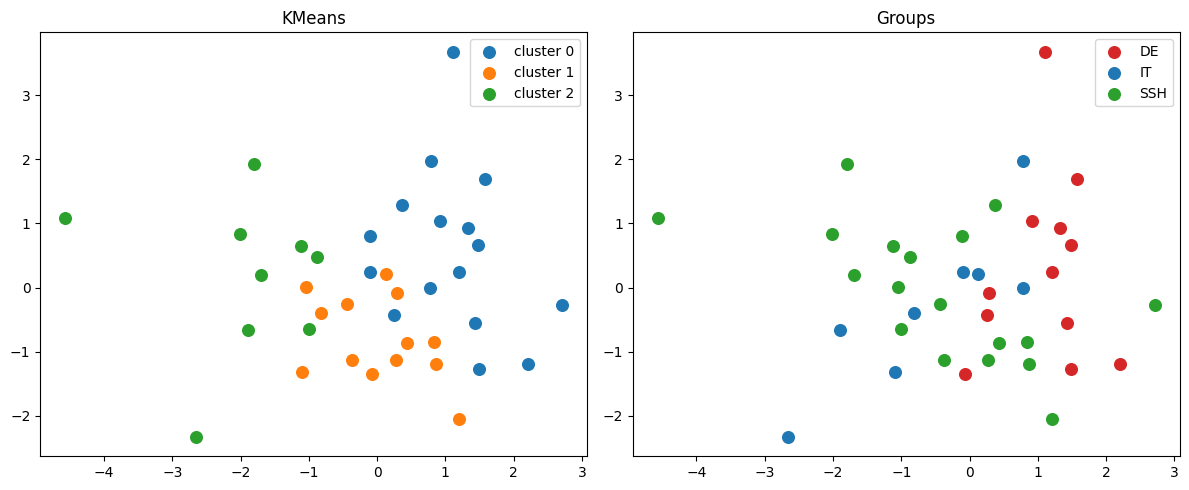

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for c in sorted(results["cluster"].unique()):
    mask = results["cluster"] == c
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], label=f"cluster {c}", s=70)
axes[0].set_title("KMeans")
axes[0].legend()

colors = {"DE": "tab:red", "IT": "tab:blue", "SSH": "tab:green"}
for g, col in colors.items():
    mask = results["group"] == g
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], label=g, s=70, c=col)
axes[1].set_title("Groups")
axes[1].legend()

plt.tight_layout()
plt.savefig("img/KMeans.png", dpi=110, bbox_inches="tight")
plt.show()

## TF-IDF

TF-IDF wektoruje słownictwo każdego uczestnika, dzięki czemu klastrowanie może wychwycić różnice (np. terminologia ekspercka vs. język opisowy studentów).

- TfidfVectorizer z czyszczeniem wstawek ((anonimizacja), (ns - 00:02:21), itp.) i odfiltrowaniem tokenów numerycznych
- TruncatedSVD (LSA) -> 15 wymiarów


In [14]:
from src.features import tfidf_svd_features, top_terms_per_cluster

tfidf_feats = tfidf_svd_features(text_df, n_components=15)
print("TF-IDF SVD shape:", tfidf_feats.shape)
tfidf_feats.head()

TF-IDF SVD shape: (38, 15)


,tfidf_svd_1,tfidf_svd_2,tfidf_svd_3,tfidf_svd_4,tfidf_svd_5,tfidf_svd_6,tfidf_svd_7,tfidf_svd_8,tfidf_svd_9,tfidf_svd_10,tfidf_svd_11,tfidf_svd_12,tfidf_svd_13,tfidf_svd_14,tfidf_svd_15
participant_id,,,,,,,,,,,,,,,
DR_IT_05,0.430613,-0.055332,0.159479,0.005885,0.004063,0.254514,0.176209,0.036069,0.055585,0.355484,0.638657,0.041001,0.179856,0.012158,0.232304
DR_SSH_01,0.494999,-0.205234,-0.117563,-0.396480,0.063386,-0.042218,-0.122658,0.313331,0.021101,0.112650,-0.034300,-0.133534,0.116762,-0.220390,-0.068849
DR_SSH_02,0.655647,-0.193376,0.102681,-0.113027,0.149099,0.276274,0.102139,0.156463,-0.094048,-0.014038,-0.072016,-0.018112,0.028562,0.009769,-0.084514
DR_SSH_03,0.471824,-0.163266,-0.238041,-0.351483,0.186360,0.007354,-0.063531,0.243375,-0.195231,0.101905,0.051601,-0.113927,0.032108,0.205526,-0.041245
DR_SSH_04,0.544986,-0.146076,-0.174186,-0.218988,-0.108258,-0.207353,-0.191097,0.077624,0.256422,0.099216,0.042897,0.146914,-0.055151,-0.032351,-0.030700


In [15]:
X_tfidf = tfidf_feats.values
kmeans_tfidf = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters_tfidf = kmeans_tfidf.fit_predict(X_tfidf)

results_tfidf = pd.DataFrame(
    {
        "participant_id": tfidf_feats.index.tolist(),
        "cluster": clusters_tfidf,
    }
).merge(text_df[["participant_id", "group"]], on="participant_id")

pd.crosstab(
    results_tfidf["cluster"], results_tfidf["group"], margins=True, margins_name="Razem"
)

group,DE,IT,SSH,Razem
cluster,,,,
0,1,4,5,10
1,0,4,12,16
2,11,0,1,12
Razem,12,8,18,38


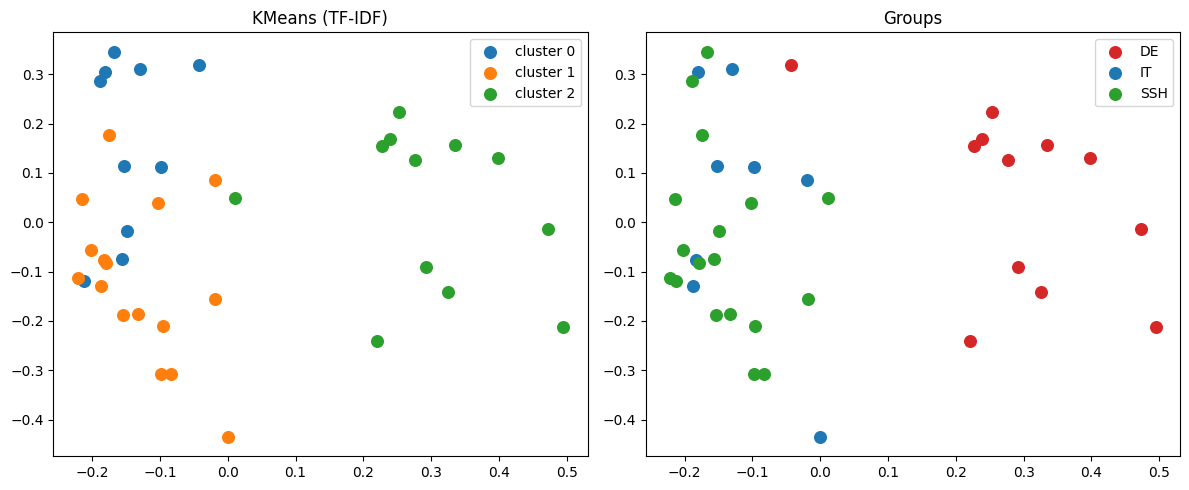

In [16]:
X_tfidf_2d = PCA(n_components=2, random_state=42).fit_transform(X_tfidf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for c in sorted(results_tfidf["cluster"].unique()):
    mask = results_tfidf["cluster"] == c
    axes[0].scatter(
        X_tfidf_2d[mask, 0], X_tfidf_2d[mask, 1], label=f"cluster {c}", s=70
    )
axes[0].set_title("KMeans (TF-IDF)")
axes[0].legend()

colors = {"DE": "tab:red", "IT": "tab:blue", "SSH": "tab:green"}
for g, col in colors.items():
    mask = results_tfidf["group"] == g
    axes[1].scatter(X_tfidf_2d[mask, 0], X_tfidf_2d[mask, 1], label=g, s=70, c=col)
axes[1].set_title("Groups")
axes[1].legend()

plt.tight_layout()
plt.savefig("img/KMeans_tfidf.png", dpi=110, bbox_inches="tight")
plt.show()

In [17]:
top_terms = top_terms_per_cluster(text_df, clusters_tfidf, top_k=10)
for cluster_id, terms in top_terms.items():
    print(f"Cluster {cluster_id}:", ", ".join(t for t, _ in terms))

Cluster 0: mamy, ok, myślę, sumie, brak, wpływ, wartość, wydaje, stanie, trochę
Cluster 1: właśnie, raczej, wydaje, myślę, wartość, trochę, mamy, faktycznie, naprawdę, znaczy
Cluster 2: mhm, mamy, znaczy, właśnie, yy, brak, gatunków, gatunki, blaszki, powiem


### TF-IDF + STAT

Łączymy obie reprezentacje (każda standaryzowana osobno, żeby skala nie faworyzowała żadnej z nich) i klastrujemy ponownie.


In [18]:
import numpy as np

X_combined = np.hstack(
    [
        StandardScaler().fit_transform(feats.loc[tfidf_feats.index].values),
        StandardScaler().fit_transform(tfidf_feats.values),
    ]
)
kmeans_combined = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters_combined = kmeans_combined.fit_predict(X_combined)

results_combined = pd.DataFrame(
    {
        "participant_id": tfidf_feats.index.tolist(),
        "cluster": clusters_combined,
    }
).merge(text_df[["participant_id", "group"]], on="participant_id")

pd.crosstab(
    results_combined["cluster"],
    results_combined["group"],
    margins=True,
    margins_name="Razem",
)

group,DE,IT,SSH,Razem
cluster,,,,
0,2,3,7,12
1,1,3,10,14
2,9,2,1,12
Razem,12,8,18,38


### Porównanie

ARI (Adjusted Rand Index) i NMI (Normalized Mutual Information) względem prawdziwych grup DE/IT/SSH. Wyższe = klastry lepiej odzwierciedlają rzeczywiste grupy. Zerowy ARI to losowe przypisanie, ARI=1 to idealna zgodność.


In [19]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ordered_ids = tfidf_feats.index
groups_true = text_df.set_index("participant_id").loc[ordered_ids, "group"].values


def score(predicted):
    return {
        "ARI": adjusted_rand_score(groups_true, predicted),
        "NMI": normalized_mutual_info_score(groups_true, predicted),
    }


pd.DataFrame(
    {
        "simple_features": score(clusters),
        "tfidf_svd": score(clusters_tfidf),
        "combined": score(clusters_combined),
    }
).T.round(3)

,ARI,NMI
simple_features,0.144,0.204
tfidf_svd,0.392,0.443
combined,0.202,0.220


## PROBLEMS_RESPONSES

PROBLEMS_RESPONSES.csv zawiera, dla każdego uczestnika i dla każdego z grzybów, decyzję (jadalny/trujący) oraz samoocenianą pewność w 5-stopniowej skali. Łącznie 78 wierszy = 26 uczestników x 3 problemy.

Z tego dostajemy 4 cechy per uczestnik:

- accuracy - ratio decyzji zgodnych z prawdą
- mean_certainty - średni wynik na skali od -2 do +2
- frac_cant_assess - ratio decyzji o odmowie oceny
- overconfidence - liczba decyzji błędnych przy pewności >= +1

Ograniczenie: ten plik nie zawiera żadnych odpowiedzi z grupy DE. Przez te braki można dobrze zidentyfikować grupę DE - trywialne klastrowanie (sygnał grupy).

Dwa warianty:

1. n = 26: odróżnianie IT od SSH
2. n = 38 z imputacją


In [20]:
from src.responses import load_problems_responses, load_problems, response_features

responses = load_problems_responses()
problems = load_problems()
resp_feats = response_features(responses, problems)

print(
    "Pokrycie:",
    len(resp_feats),
    "/",
    text_df["participant_id"].nunique(),
    "uczestników",
)
resp_feats.head(10).round(2)

Pokrycie: 26 / 38 uczestników


,accuracy,mean_certainty,frac_cant_assess,overconfidence
participant_id,,,,
DR_IT_05,0.67,-1.33,0.00,0
DR_SSH_01,0.0,1.33,0.00,3
DR_SSH_02,0.33,0.00,0.33,1
DR_SSH_03,0.0,0.67,0.33,2
DR_SSH_04,0.33,-1.00,0.00,1
DR_SSH_06,0.0,-1.00,0.00,0
DR_SSH_07,0.67,1.00,0.00,1
MK_IT_03,0.33,1.00,0.00,2
MK_IT_06,0.33,2.00,0.00,2


In [21]:
resp_feats.join(text_df.set_index("participant_id")["group"]).groupby("group").mean(
    numeric_only=True
).round(2)

,accuracy,mean_certainty,frac_cant_assess,overconfidence
group,,,,
IT,0.42,0.71,0.12,1.25
SSH,0.33,0.13,0.13,1.06


TF-IDF wcześniej wyizolował klaster DE (klaster 2 = 11/12 ekspertów). Pytanie: czy studentów IT i SSH da się rozróżnić? TF-IDF refittujemy na podzbiorze, KMeans k=2.


In [22]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

subset_ids = resp_feats.index.tolist()
text_sub = text_df[text_df["participant_id"].isin(subset_ids)].reset_index(drop=True)

tfidf_sub = tfidf_svd_features(text_sub, n_components=10)
beh_sub = resp_feats.loc[tfidf_sub.index]

X_tfidf_sub = StandardScaler().fit_transform(tfidf_sub.values)
X_beh_sub = StandardScaler().fit_transform(beh_sub.values)
X_comb_sub = np.hstack([X_tfidf_sub, X_beh_sub])

clusters_tfidf_sub = KMeans(n_clusters=2, random_state=42, n_init=20).fit_predict(
    X_tfidf_sub
)
clusters_beh_sub = KMeans(n_clusters=2, random_state=42, n_init=20).fit_predict(
    X_beh_sub
)
clusters_comb_sub = KMeans(n_clusters=2, random_state=42, n_init=20).fit_predict(
    X_comb_sub
)

groups_sub = text_sub.set_index("participant_id").loc[tfidf_sub.index, "group"].values


def score_sub(c):
    return {
        "ARI": adjusted_rand_score(groups_sub, c),
        "NMI": normalized_mutual_info_score(groups_sub, c),
    }


pd.DataFrame(
    {
        "tfidf_sub": score_sub(clusters_tfidf_sub),
        "behavioral_sub": score_sub(clusters_beh_sub),
        "tfidf + beh_sub": score_sub(clusters_comb_sub),
    }
).T.round(3)

,ARI,NMI
tfidf_sub,-0.014,0.008
behavioral_sub,0.063,0.088
tfidf + beh_sub,-0.047,0.006


In [23]:
pd.crosstab(
    pd.Series(clusters_comb_sub, name="cluster"),
    pd.Series(groups_sub, name="group"),
    margins=True,
    margins_name="Razem",
)

group,IT,SSH,Razem
cluster,,,
0,2,6,8
1,6,12,18
Razem,8,18,26


Ani TF-IDF, ani cechy behawioralne, ani ich połączenie nie oddzielają IT od SSH. Sygnał między studentami informatyki a SSH jest na tym poziomie reprezentacji bardzo słaby - klastrowanie odbija po prostu liczność grup.

#### n = 38

Doklejamy cechy behawioralne do TF-IDF dla wszystkich 38 uczestników. Braki dla 12 osób z DE wypełniamy medianą obliczoną na IT + SSH.

W wariantach łączonych obie reprezentacje standaryzujemy (StandardScaler), żeby skala nie faworyzowała jednej z nich.


In [24]:
beh_aligned = resp_feats.reindex(tfidf_feats.index)
beh_imputed = beh_aligned.fillna(beh_aligned.median(numeric_only=True))

X_tfidf_scaled = StandardScaler().fit_transform(tfidf_feats.values)
X_beh_scaled = StandardScaler().fit_transform(beh_imputed.values)
X_tfidf_beh = np.hstack([X_tfidf_scaled, X_beh_scaled])

clusters_tfidf_scaled = KMeans(n_clusters=3, random_state=42, n_init=20).fit_predict(
    X_tfidf_scaled
)
clusters_tfidf_beh = KMeans(n_clusters=3, random_state=42, n_init=20).fit_predict(
    X_tfidf_beh
)

results_tfidf_beh = pd.DataFrame(
    {
        "participant_id": tfidf_feats.index.tolist(),
        "cluster": clusters_tfidf_beh,
    }
).merge(text_df[["participant_id", "group"]], on="participant_id")

pd.crosstab(
    results_tfidf_beh["cluster"],
    results_tfidf_beh["group"],
    margins=True,
    margins_name="Razem",
)

group,DE,IT,SSH,Razem
cluster,,,,
0,11,0,2,13
1,1,5,6,12
2,0,3,10,13
Razem,12,8,18,38


In [25]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ordered_ids = tfidf_feats.index
groups_true = text_df.set_index("participant_id").loc[ordered_ids, "group"].values


def score(predicted):
    return {
        "ARI": adjusted_rand_score(groups_true, predicted),
        "NMI": normalized_mutual_info_score(groups_true, predicted),
    }


pd.DataFrame(
    {
        "simple_features": score(clusters),
        "tfidf_svd": score(clusters_tfidf),
        "tfidf_svd (scaled)": score(clusters_tfidf_scaled),
        "simple + tfidf": score(clusters_combined),
        "tfidf_svd + beh (imputed)": score(clusters_tfidf_beh),
    }
).T.round(3)

,ARI,NMI
simple_features,0.144,0.204
tfidf_svd,0.392,0.443
tfidf_svd (scaled),0.322,0.314
simple + tfidf,0.202,0.220
tfidf_svd + beh (imputed),0.326,0.396


Otrzymujemy wyniki gorsze niż w naturalnym działaniu TF-IDF.


## MAXQDA_SUMMARY

MAXQDA_SUMMARY.csv zawiera ręcznie nadane zliczenia kodów tematycznych per uczestnik.


In [26]:
from src.maxqda import (
    load_maxqda_summary,
    code_count_features,
    top_codes_per_group,
)

maxqda = load_maxqda_summary()
maxqda_feats = code_count_features(maxqda, normalize=True)
print("Code matrix shape:", maxqda_feats.shape)
print(
    "Coverage:",
    maxqda_feats.index.isin(text_df["participant_id"]).sum(),
    "/",
    len(text_df),
)
maxqda_feats.iloc[:5, :6].round(3)

Code matrix shape: (38, 82)
Coverage: 38 / 38


,aesthetics,aesthetics > colour scheme,aesthetics > font size,aesthetics > layout,affects,affects > interest
participant_id,,,,,,
DR_IT_05,0.000,0.000,0.000,0.000,0.0,0.00
DR_SSH_01,0.016,0.031,0.008,0.008,0.0,0.00
DR_SSH_02,0.008,0.029,0.005,0.013,0.0,0.00
DR_SSH_03,0.000,0.010,0.000,0.000,0.0,0.01
DR_SSH_04,0.000,0.000,0.000,0.000,0.0,0.00


In [ ]:
groups_map = text_df.set_index("participant_id")["group"]
top_codes = top_codes_per_group(maxqda, groups_map, top_k=8)

for grp in ["DE", "IT", "SSH"]:
    print(f"Top 8 codes for {grp}")
    for code, val in top_codes[grp].items():
        print(f"  {val:.3f}  {code}")
    print()

=== Top 8 codes for DE ===
  0.097  knowledge and experience > knowledge and experience in fungi
  0.067  evaluation criteria > importance
  0.058  evaluation criteria > unreadability
  0.057  methods of analysis > taxons
  0.051  methods of analysis > omission
  0.040  data and features > feature significance
  0.037  knowledge and experience > knowledge and experience in fungi > names and species of fungi
  0.036  evaluation criteria > representativeness

=== Top 8 codes for IT ===
  0.099  evaluation criteria > comprehensibility
  0.076  data and features > understanding of annotations
  0.063  data and features > feature significance
  0.060  evaluation criteria > unreadability
  0.045  evaluation criteria > appropriateness
  0.036  methods of analysis > example analysis
  0.026  methods of analysis > difficulties
  0.023  knowledge and experience > knowledge and experience in visualizations and analysis

=== Top 8 codes for SSH ===
  0.094  evaluation criteria > comprehensibility


In [28]:
ordered_ids = tfidf_feats.index
X_maxqda = StandardScaler().fit_transform(maxqda_feats.loc[ordered_ids].values)

clusters_maxqda = KMeans(n_clusters=3, random_state=42, n_init=20).fit_predict(X_maxqda)

results_maxqda = pd.DataFrame(
    {"participant_id": ordered_ids.tolist(), "cluster": clusters_maxqda}
).merge(text_df[["participant_id", "group"]], on="participant_id")

pd.crosstab(
    results_maxqda["cluster"],
    results_maxqda["group"],
    margins=True,
    margins_name="Razem",
)

group,DE,IT,SSH,Razem
cluster,,,,
0,12,0,0,12
1,0,6,10,16
2,0,2,8,10
Razem,12,8,18,38


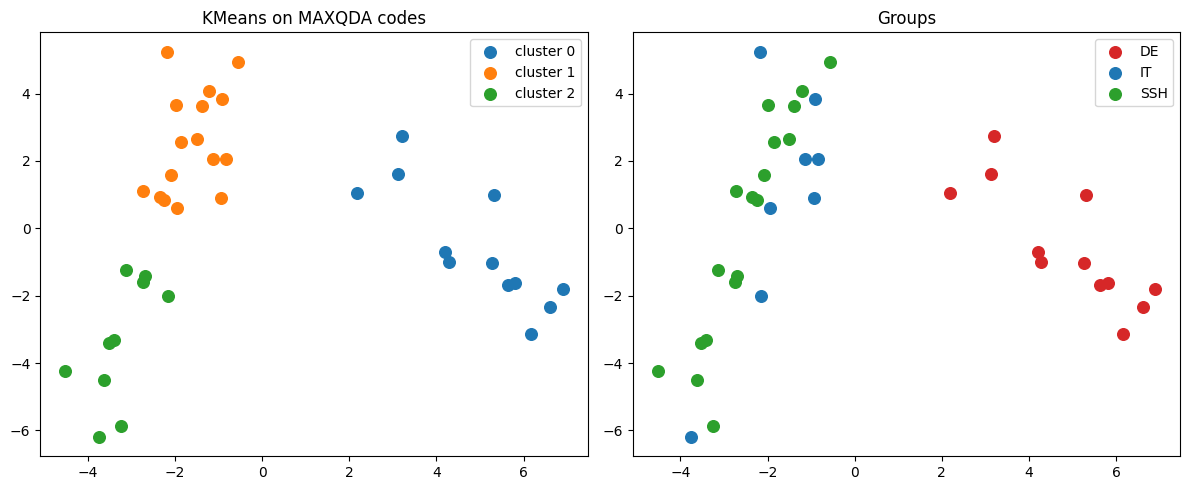

In [ ]:
X_maxqda_2d = PCA(n_components=2, random_state=42).fit_transform(X_maxqda)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for c in sorted(results_maxqda["cluster"].unique()):
    mask = results_maxqda["cluster"] == c
    axes[0].scatter(
        X_maxqda_2d[mask, 0], X_maxqda_2d[mask, 1], label=f"cluster {c}", s=70
    )
axes[0].set_title("KMeans (MAXQDA)")
axes[0].legend()

colors = {"DE": "tab:red", "IT": "tab:blue", "SSH": "tab:green"}
for g, col in colors.items():
    mask = results_maxqda["group"] == g
    axes[1].scatter(X_maxqda_2d[mask, 0], X_maxqda_2d[mask, 1], label=g, s=70, c=col)
axes[1].set_title("Groups")
axes[1].legend()

plt.tight_layout()
plt.savefig("img/KMeans_maxqda.png", dpi=110, bbox_inches="tight")
plt.show()

In [ ]:
X_tfidf_scaled_for_maxqda = StandardScaler().fit_transform(
    tfidf_feats.loc[ordered_ids].values
)
X_tfidf_maxqda = np.hstack([X_tfidf_scaled_for_maxqda, X_maxqda])

clusters_tfidf_maxqda = KMeans(n_clusters=3, random_state=42, n_init=20).fit_predict(
    X_tfidf_maxqda
)

results_tfidf_maxqda = pd.DataFrame(
    {"participant_id": ordered_ids.tolist(), "cluster": clusters_tfidf_maxqda}
).merge(text_df[["participant_id", "group"]], on="participant_id")

pd.crosstab(
    results_tfidf_maxqda["cluster"],
    results_tfidf_maxqda["group"],
    margins=True,
    margins_name="Razem",
)

group,DE,IT,SSH,Razem
cluster,,,,
0,0,2,8,10
1,12,0,0,12
2,0,6,10,16
Razem,12,8,18,38


### Porównanie z MAXQDA

Dwa nowe warianty: MAXQDA samodzielnie (82 kody) oraz TF-IDF + MAXQDA. Drugi wariant w praktyce daje identyczny wynik co MAXQDA samo - macierz MAXQDA (82 wymiary) dominuje TF-IDF (15) przez sam rozmiar bloków po standaryzacji.


In [31]:
pd.DataFrame(
    {
        "simple_features": score(clusters),
        "tfidf_svd": score(clusters_tfidf),
        "tfidf_svd (scaled)": score(clusters_tfidf_scaled),
        "simple + tfidf": score(clusters_combined),
        "tfidf_svd + beh (imputed)": score(clusters_tfidf_beh),
        "maxqda (82 codes)": score(clusters_maxqda),
        "tfidf + maxqda": score(clusters_tfidf_maxqda),
    }
).T.round(3)

,ARI,NMI
simple_features,0.144,0.204
tfidf_svd,0.392,0.443
tfidf_svd (scaled),0.322,0.314
simple + tfidf,0.202,0.220
tfidf_svd + beh (imputed),0.326,0.396
maxqda (82 codes),0.468,0.598
tfidf + maxqda,0.468,0.598


MAXQDA wygrywa z każdym wcześniejszym wariantem (ARI 0.47, NMI 0.60). Ręczne kodowanie tematyczne wprost zawiera sygnał, który TF-IDF musiał aproksymować przez słownictwo. Klaster 1 to 12/12 ekspertów DE, w obrębie studentów IT (6/8) i SSH (10/18) zaczynają tworzyć różne klastry zamiast mieszać się w jednym.
